In [15]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None) # show every column
pd.options.display.float_format = "{:,.0f}".format # 1234567.0 -> 1,234,567

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.0f}".format

# Random number generator
rng = np.random.default_rng(42)

# Example customers DataFrame
# If you already created customers earlier, keep your existing one instead.
customers = pd.DataFrame({
    "customer_id": range(1001, 1101)
})

catalog = {
    "Electronics": [
        ("Wireless Earbuds", 59000),
        ("Phone Charger", 25000),
        ("Smart Watch", 189000)
    ],
    "Home & Kitchen": [
        ("Air Fryer", 99000),
        ("Rice Cooker", 129000),
        ("Water Bottle", 18000)
    ],
    "Fashion": [
        ("Running Shoes", 89000),
        ("Winter Jacket", 159000),
        ("Backpack", 49000)
    ],
    "Beauty": [
        ("Sunscreen", 22000),
        ("Face Serum", 45000),
        ("Hand Cream", 12000)
    ],
}

n = 300
rows = []

for i in range(n):
    cat = rng.choice(list(catalog))
    prod, price = catalog[cat][rng.integers(0, 3)]

    day = (
        pd.Timestamp("2026-03-01")
        + pd.Timedelta(days=int(rng.integers(0, 180)))
    )

    rows.append({
        "order_id": 5001 + i,
        "customer_id": int(
            rng.choice(customers["customer_id"].iloc[:50])
        ),
        "order_date": day.strftime("%Y-%m-%d"),
        "category": cat,
        "product": prod,
        "unit_price": f"\u20a9{price:,}",
        "quantity": float(rng.integers(1, 5)),
        "payment_method": rng.choice(
            ["Card", "KakaoPay", "Bank Transfer"]
        ),
    })

orders = pd.DataFrame(rows)

# ---- make the data realistically messy ----
orders.loc[
    rng.choice(n, 15, replace=False), "quantity"
] = np.nan

orders.loc[
    rng.choice(n, 20, replace=False), "payment_method"
] = np.nan

orders.loc[
    rng.choice(n, 40, replace=False), "category"
] = orders["category"].str.lower()

orders.loc[
    rng.choice(n, 25, replace=False), "category"
] = " " + orders["category"] + " "

orders.loc[[10, 11, 12], "customer_id"] = 9999

orders = pd.concat(
    [orders, orders.sample(12, random_state=1)],
    ignore_index=True
)

orders = orders.sample(
    frac=1,
    random_state=7
).reset_index(drop=True)

orders.to_csv(
    "orders_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

customers.to_csv(
    "customers.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Created orders_raw.csv and customers.csv")


Created orders_raw.csv and customers.csv


In [18]:
orders = pd.read_csv("orders_raw.csv")
customers = pd.read_csv("customers.csv")
print("orders :", orders.shape)
print("customers:", customers.shape)
orders.head(8)

orders : (312, 8)
customers: (100, 1)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method
0,5285,1046,2026-08-25,beauty,Hand Cream,"₩12,000",1,Card
1,5171,1043,2026-08-04,Electronics,Wireless Earbuds,"₩59,000",4,Card
2,5151,1045,2026-04-09,Electronics,Wireless Earbuds,"₩59,000",2,Bank Transfer
3,5105,1019,2026-04-30,Fashion,Running Shoes,"₩89,000",3,KakaoPay
4,5038,1016,2026-07-08,Fashion,Running Shoes,"₩89,000",NaN,KakaoPay
5,5102,1043,2026-08-22,Home & Kitchen,Rice Cooker,"₩129,000",4,KakaoPay
6,5267,1036,2026-07-31,Fashion,Backpack,"₩49,000",2,Bank Transfer
7,5243,1004,2026-06-11,Electronics,Wireless Earbuds,"₩59,000",4,KakaoPay


In [19]:
orders.info()
print("\n--- Missing values per column ---")
print(orders.isna().sum())
print("\nFully duplicated rows:", orders.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        312 non-null    int64  
 1   customer_id     312 non-null    int64  
 2   order_date      312 non-null    str    
 3   category        312 non-null    str    
 4   product         312 non-null    str    
 5   unit_price      312 non-null    str    
 6   quantity        297 non-null    float64
 7   payment_method  292 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 19.6 KB

--- Missing values per column ---
order_id           0
customer_id        0
order_date         0
category           0
product            0
unit_price         0
quantity          15
payment_method    20
dtype: int64

Fully duplicated rows: 12


In [20]:
print(orders["category"].value_counts())
print("\nSample prices:", orders["unit_price"].head(3).tolist())

category
Fashion             67
Home & Kitchen      63
Beauty              61
Electronics         55
beauty              14
fashion             10
 Electronics         8
electronics          8
 Home & Kitchen      8
home & kitchen       7
 Fashion             5
 Beauty              4
 home & kitchen      1
 fashion             1
Name: count, dtype: int64

Sample prices: ['₩12,000', '₩59,000', '₩59,000']


In [21]:
print(orders["category"].value_counts())
print("\nSample prices:", orders["unit_price"].head(3).tolist())

category
Fashion             67
Home & Kitchen      63
Beauty              61
Electronics         55
beauty              14
fashion             10
 Electronics         8
electronics          8
 Home & Kitchen      8
home & kitchen       7
 Fashion             5
 Beauty              4
 home & kitchen      1
 fashion             1
Name: count, dtype: int64

Sample prices: ['₩12,000', '₩59,000', '₩59,000']


In [22]:
# Price: strip the won sign and commas, then convert to float
orders["unit_price"] = (
orders["unit_price"]
.str.replace("\u20a9", "", regex=False)
.str.replace(",", "", regex=False)
.astype(float)
)
# Date: text -> real datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders.dtypes

order_id                   int64
customer_id                int64
order_date        datetime64[us]
category                     str
product                      str
unit_price               float64
quantity                 float64
payment_method               str
dtype: object

In [23]:
orders["category"] = orders["category"].str.strip().str.title()
orders["category"].value_counts()

category
Fashion           83
Beauty            79
Home & Kitchen    79
Electronics       71
Name: count, dtype: int64

In [24]:
# Quantity is numeric -> fill with the median (robust to outliers)
orders["quantity"] = orders["quantity"].fillna(orders["quantity"].median()).astype(int)
# Payment method is text -> fill with an honest placeholder
orders["payment_method"] = orders["payment_method"].fillna("Unknown")
print("Missing values left:", orders.isna().sum().sum())

Missing values left: 0


In [25]:
orders["revenue"] = orders["unit_price"] * orders["quantity"]
orders["month"] = orders["order_date"].dt.strftime("%Y-%m")
orders.head()

,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month
0,5285,1046,2026-08-25,Beauty,Hand Cream,"12,000",1,Card,"12,000",2026-08
1,5171,1043,2026-08-04,Electronics,Wireless Earbuds,"59,000",4,Card,"236,000",2026-08
2,5151,1045,2026-04-09,Electronics,Wireless Earbuds,"59,000",2,Bank Transfer,"118,000",2026-04
3,5105,1019,2026-04-30,Fashion,Running Shoes,"89,000",3,KakaoPay,"267,000",2026-04
4,5038,1016,2026-07-08,Fashion,Running Shoes,"89,000",2,KakaoPay,"178,000",2026-07


In [26]:
print("Orders before merge:", len(orders))
inner = pd.merge(orders, customers, on="customer_id", how="inner")
print("Rows after INNER join:", len(inner))
merged = pd.merge(orders, customers, on="customer_id", how="left", indicator=True)
print("Rows after LEFT join :", len(merged))
merged["_merge"].value_counts()

Orders before merge: 312
Rows after INNER join: 309
Rows after LEFT join : 312


_merge
both          309
left_only       3
right_only      0
Name: count, dtype: int64

In [27]:
orphans = merged[merged["_merge"] == "left_only"]
orphans[["order_id", "customer_id", "revenue"]]


,order_id,customer_id,revenue
107,5012,9999,"180,000"
251,5013,9999,"198,000"
275,5011,9999,"24,000"


In [28]:
merged = orders.merge(
    customers,
    on="customer_id",
    how="left",
    indicator=True
)


['order_id', 'customer_id', 'order_date', 'category', 'product', 'unit_price', 'quantity', 'payment_method', 'revenue', 'month', '_merge']
   order_id  customer_id order_date     category           product  \
0      5285         1046 2026-08-25       Beauty        Hand Cream   
1      5171         1043 2026-08-04  Electronics  Wireless Earbuds   
2      5151         1045 2026-04-09  Electronics  Wireless Earbuds   
3      5105         1019 2026-04-30      Fashion     Running Shoes   
4      5038         1016 2026-07-08      Fashion     Running Shoes   

   unit_price  quantity payment_method  revenue    month _merge  
0      12,000         1           Card   12,000  2026-08   both  
1      59,000         4           Card  236,000  2026-08   both  
2      59,000         2  Bank Transfer  118,000  2026-04   both  
3      89,000         3       KakaoPay  267,000  2026-04   both  
4      89,000         2       KakaoPay  178,000  2026-07   both  


In [30]:
print(merged.columns.tolist())
print(merged.head())

['order_id', 'customer_id', 'order_date', 'category', 'product', 'unit_price', 'quantity', 'payment_method', 'revenue', 'month', '_merge']
   order_id  customer_id order_date     category           product  \
0      5285         1046 2026-08-25       Beauty        Hand Cream   
1      5171         1043 2026-08-04  Electronics  Wireless Earbuds   
2      5151         1045 2026-04-09  Electronics  Wireless Earbuds   
3      5105         1019 2026-04-30      Fashion     Running Shoes   
4      5038         1016 2026-07-08      Fashion     Running Shoes   

   unit_price  quantity payment_method  revenue    month _merge  
0      12,000         1           Card   12,000  2026-08   both  
1      59,000         4           Card  236,000  2026-08   both  
2      59,000         2  Bank Transfer  118,000  2026-04   both  
3      89,000         3       KakaoPay  267,000  2026-04   both  
4      89,000         2       KakaoPay  178,000  2026-07   both  


In [33]:
df = merged.drop(columns="_merge")

print(df.shape)
df.head()

(312, 10)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month
0,5285,1046,2026-08-25,Beauty,Hand Cream,"12,000",1,Card,"12,000",2026-08
1,5171,1043,2026-08-04,Electronics,Wireless Earbuds,"59,000",4,Card,"236,000",2026-08
2,5151,1045,2026-04-09,Electronics,Wireless Earbuds,"59,000",2,Bank Transfer,"118,000",2026-04
3,5105,1019,2026-04-30,Fashion,Running Shoes,"89,000",3,KakaoPay,"267,000",2026-04
4,5038,1016,2026-07-08,Fashion,Running Shoes,"89,000",2,KakaoPay,"178,000",2026-07


In [34]:
print(f"Total revenue: \u20a9{df['revenue'].sum():,.0f}\n")
by_category = (
df.groupby("category")["revenue"]
.agg(["sum", "mean", "count"])
.sort_values("sum", ascending=False)
)
by_category

Total revenue: ₩55,406,000



,sum,mean,count
category,,,
Fashion,"19,161,000","230,855",83
Home & Kitchen,"16,113,000","203,962",79
Electronics,"15,534,000","218,789",71
Beauty,"4,598,000","58,203",79


In [36]:
by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
by_category

category
Fashion          19,161,000
Home & Kitchen   16,113,000
Electronics      15,534,000
Beauty            4,598,000
Name: revenue, dtype: float64

In [38]:
top5 = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(5)
)

top5

,customer_id,revenue
15,1016,"3,543,000"
4,1005,"3,360,000"
6,1007,"2,545,000"
5,1006,"1,946,000"
0,1001,"1,905,000"


In [40]:
big_premium = (
    df[df["revenue"] >= 300000]
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

big_premium

,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month
0,5088,1016,2026-04-27,Electronics,Smart Watch,"189,000",4,Unknown,"756,000",2026-04
1,5121,1006,2026-07-31,Electronics,Smart Watch,"189,000",4,Card,"756,000",2026-07
2,5136,1015,2026-07-02,Electronics,Smart Watch,"189,000",4,Bank Transfer,"756,000",2026-07
3,5178,1020,2026-07-14,Electronics,Smart Watch,"189,000",4,KakaoPay,"756,000",2026-07
4,5216,1001,2026-05-19,Electronics,Smart Watch,"189,000",4,KakaoPay,"756,000",2026-05
5,5030,1009,2026-07-08,Fashion,Winter Jacket,"159,000",4,KakaoPay,"636,000",2026-07
6,5237,1024,2026-08-02,Fashion,Winter Jacket,"159,000",4,Bank Transfer,"636,000",2026-08
7,5189,1034,2026-05-13,Fashion,Winter Jacket,"159,000",4,Bank Transfer,"636,000",2026-05
8,5058,1013,2026-08-10,Fashion,Winter Jacket,"159,000",4,Bank Transfer,"636,000",2026-08
9,5200,1050,2026-07-07,Fashion,Winter Jacket,"159,000",4,KakaoPay,"636,000",2026-07


In [41]:
pivot = df.pivot_table(
index="month",
columns="category",
values="revenue",
aggfunc="sum",
fill_value=0,
)
pivot["Total"] = pivot.sum(axis=1)
pivot

category,Beauty,Electronics,Fashion,Home & Kitchen,Total
month,,,,,
2026-03,"900,000","1,173,000","3,037,000","2,658,000","7,768,000"
2026-04,"666,000","2,356,000","3,056,000","2,451,000","8,529,000"
2026-05,"899,000","2,265,000","3,906,000","1,737,000","8,807,000"
2026-06,"487,000","3,270,000","1,363,000","3,018,000","8,138,000"
2026-07,"753,000","4,835,000","4,874,000","2,679,000","13,141,000"
2026-08,"893,000","1,635,000","2,925,000","3,570,000","9,023,000"


In [42]:
long = (
pivot.drop(columns="Total")
.reset_index()
.melt(id_vars="month", var_name="category", value_name="revenue")
)
print(long.shape)
long.head(8)

(24, 3)


,month,category,revenue
0,2026-03,Beauty,"900,000"
1,2026-04,Beauty,"666,000"
2,2026-05,Beauty,"899,000"
3,2026-06,Beauty,"487,000"
4,2026-07,Beauty,"753,000"
5,2026-08,Beauty,"893,000"
6,2026-03,Electronics,"1,173,000"
7,2026-04,Electronics,"2,356,000"


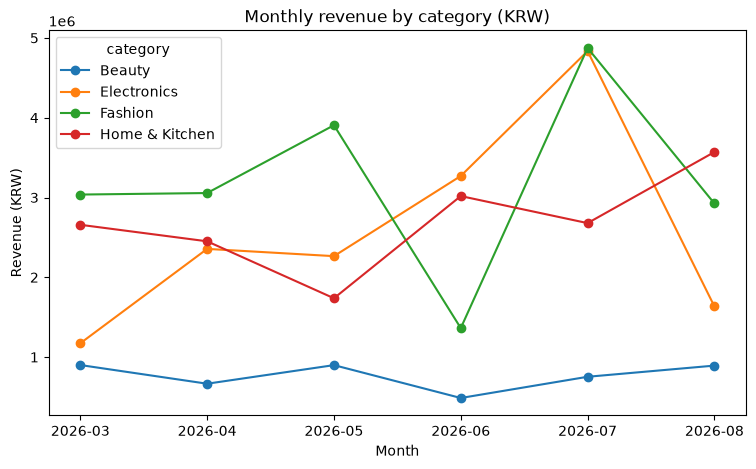

In [43]:
pivot.drop(columns="Total").plot(kind="line", marker="o", figsize=(9, 5),
title="Monthly revenue by category (KRW)")
plt.ylabel("Revenue (KRW)")
plt.xlabel("Month")
plt.show()

In [44]:
df.to_csv("orders_clean.csv", index=False)
print("Saved orders_clean.csv with", df.shape[0], "rows and", df.shape[1], "columns")

Saved orders_clean.csv with 312 rows and 10 columns
